# Семинар 6 - Классические алгоритмы сегментации изображения и обнаружения объектов

**Данный семинар содержит ДЗ**

***

In [73]:
import random as rng

import cv2
import numpy as np
import matplotlib.pyplot as plt

rng.seed(12345)

In [74]:
# !mkdir -p data
# !wget https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png -O data/cards.png

# Image Segmentation with Distance Transform and Watershed Algorithm

Источник - https://docs.opencv.org/3.4/d2/dbd/tutorial_distance_transform.html

В этом семинаре вы узнаете, как:

- Использовать `cv2.filter2D`, чтобы выполнить фильтрацию Лапласа для повышения резкости изображения.
- Использовать `cv2.distanceTransform`, чтобы получить производное представление двоичного изображения, где значение каждого пикселя заменяется его расстоянием до ближайшего пикселя фона.
- Использовать `cv2.watershed`, чтобы изолировать объекты на изображении от фона.

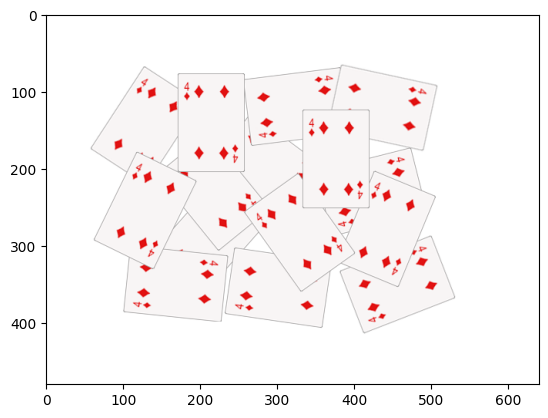

In [75]:
img_src = cv2.cvtColor(cv2.imread("data/cards.png"), cv2.COLOR_BGR2RGB)
plt.imshow(img_src);

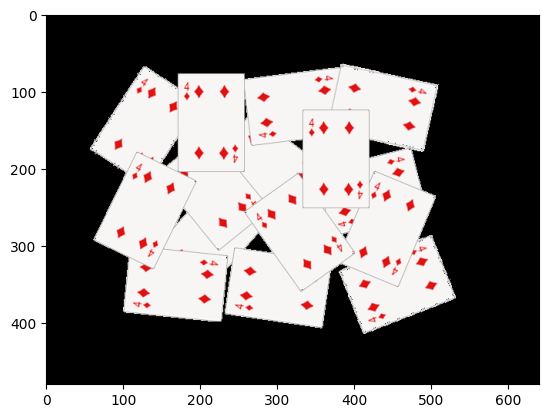

In [76]:
# Change the background from white to black, since that will help later to extract
# better results during the use of Distance Transform
img = img_src.copy()
img[np.all(img == 255, axis=2)] = 0

plt.imshow(img);

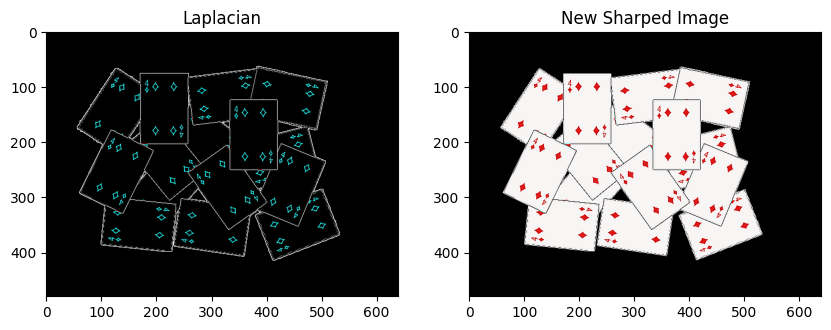

In [77]:
# Create a kernel that we will use to sharpen our image
# an approximation of second derivative, a quite strong kernel
kernel = np.array(
    [[  1,  1,  1],
     [  1, -8,  1],
     [  1,  1,  1]], dtype=np.float32)
# do the laplacian filtering as it is
# well, we need to convert everything in something more deeper then CV_8U
# because the kernel has some negative values,
# and we can expect in general to have a Laplacian image with negative values
# BUT a 8bits unsigned int (the one we are working with) can contain values from 0 to 255
# so the possible negative number will be truncated
imgLaplacian = cv2.filter2D(img, cv2.CV_32F, kernel)
sharp = np.float32(img)
imgResult = sharp - imgLaplacian

# convert back to 8bits gray scale
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
imgLaplacian = np.clip(imgLaplacian, 0, 255)
imgLaplacian = np.uint8(imgLaplacian)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(imgLaplacian)
plt.title('Laplacian')
plt.subplot(122)
plt.imshow(imgResult)
plt.title('New Sharped Image');

### Бинаризация изображения

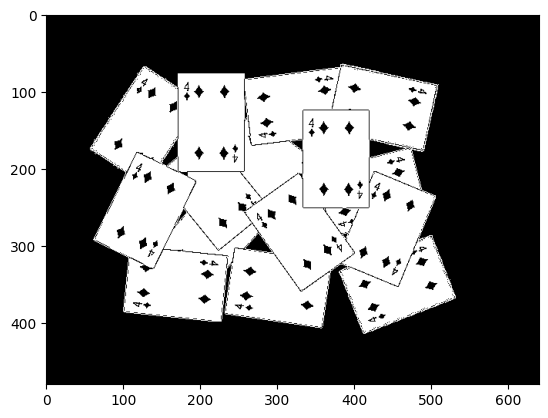

In [78]:
# Create binary image from source image
bw = cv2.cvtColor(imgResult, cv2.COLOR_BGR2GRAY)
_, bw = cv2.threshold(bw, 40, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(bw, cmap="Greys_r");

### Distance transform

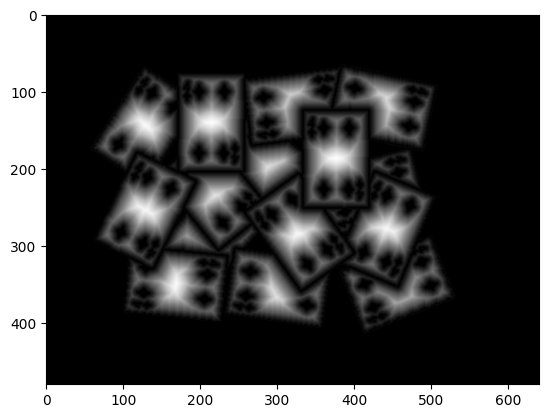

In [79]:
# Perform the distance transform algorithm
dist = cv2.distanceTransform(bw, cv2.DIST_L2, 3)
# Normalize the distance image for range = {0.0, 1.0}
# so we can visualize and threshold it
cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
plt.imshow(dist, cmap="Greys_r");

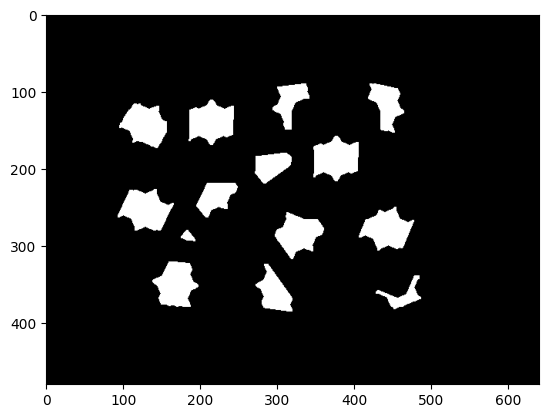

In [80]:
# Threshold to obtain the peaks
# This will be the markers for the foreground objects
_, dist = cv2.threshold(dist, 0.4, 1.0, cv2.THRESH_BINARY)
# Dilate a bit the dist image
kernel1 = np.ones((3,3), dtype=np.uint8)
dist = cv2.dilate(dist, kernel1)
plt.imshow(dist, cmap="Greys_r");

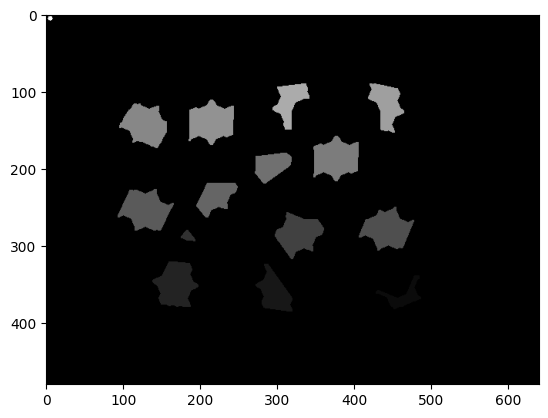

In [81]:
# Create the CV_8U version of the distance image
# It is needed for findContours()
dist_8u = dist.astype('uint8')
# Find total markers
contours, _ = cv2.findContours(dist_8u, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create the marker image for the watershed algorithm
markers = np.zeros(dist.shape, dtype=np.int32)
# Draw the foreground markers
for i in range(len(contours)):
    cv2.drawContours(
        markers,   # image
        contours,  # contours list
        i,         # contour index to draw
        (i+1),     # color (fill value)
        -1,        # thickness (if negative - fill the contour)
    )
# Draw the background marker
cv2.circle(
    markers,        # image
    (5,5),          # center
    3,              # radius
    (255,255,255),  # color
    -1,             # thickness (if negative - fill)
)

markers_8u = (markers * 10).astype('uint8')
plt.imshow(markers_8u, cmap="Greys_r");

### Алгоритм Watershed

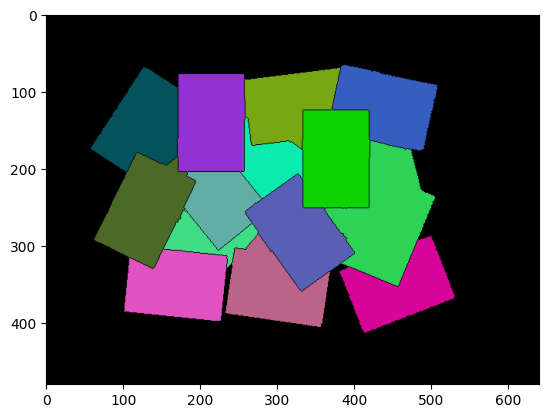

In [82]:
# Perform the watershed algorithm
cv2.watershed(imgResult, markers)

mark = markers.astype('uint8')
mark = cv2.bitwise_not(mark)
# uncomment this if you want to see how the mark
# image looks like at that point
# plt.imshow(mark)
# Generate random colors
colors = []
for contour in contours:
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))
# Create the result image
dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
# Fill labeled objects with random colors
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        if index > 0 and index <= len(contours):
            dst[i,j,:] = colors[index-1]

# Visualize the final image
plt.imshow(dst);

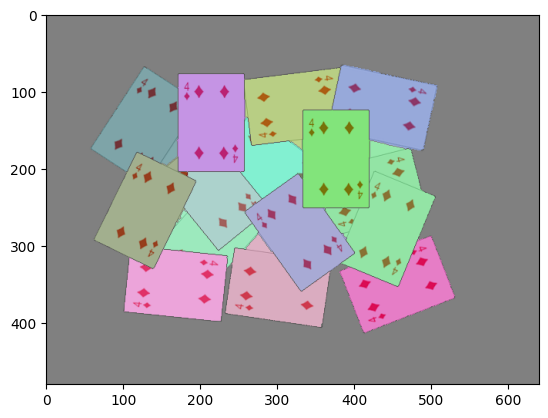

In [83]:
blended = cv2.addWeighted(img_src, 0.5, dst, 0.5, 0.0)
plt.imshow(blended);

# Домашнее задание: подсчет количества пальцев

**Это оцениваемое ДЗ**

Вам предлагается реализовать алгоритм, подсчитывающий количество пальцев.

Один из возможных вариантов решения:
- Получить бинаризованное изображение и найти контур руки;
- Построить выпуклый контур функцией `cv2.convexHull` - https://docs.opencv.org/3.4/d7/d1d/tutorial_hull.html
- Найти дефекты выпуклости контура функцией [`cv2.convexityDefects`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gada4437098113fd8683c932e0567f47ba)
- После некоторой фильтрации дефектов, их число будет напрямую коррелировать с числом пальцев.

**Требования:**
1. Продемонстрируйте работоспособность алгоритма на любом числе пальцев (от 0 до 5).
2. Используйте фото своей руки для демонстрации (предложенное фото лишь для отладки).

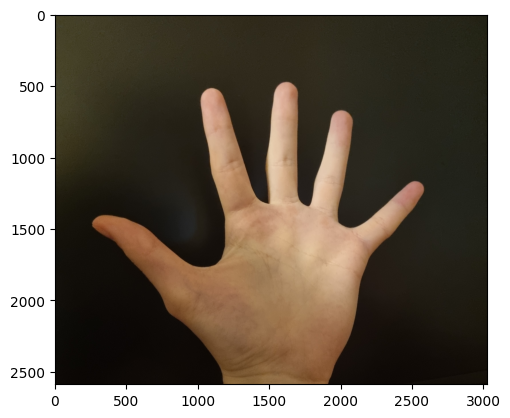

In [84]:
img = cv2.cvtColor(cv2.imread("data/cool_hand.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

### Решение ДЗ

Идея решения:

1. Сегментировать кожу в пространстве `YCrCb`.
2. Очистить бинарную маску морфологическими операциями.
3. Оставить крупнейшую связную компоненту, соответствующую кисти.
4. Найти выпуклую оболочку кисти и выбрать верхние удаленные точки как кандидаты в кончики пальцев.
5. Сгруппировать близкие по углу точки и посчитать число групп.


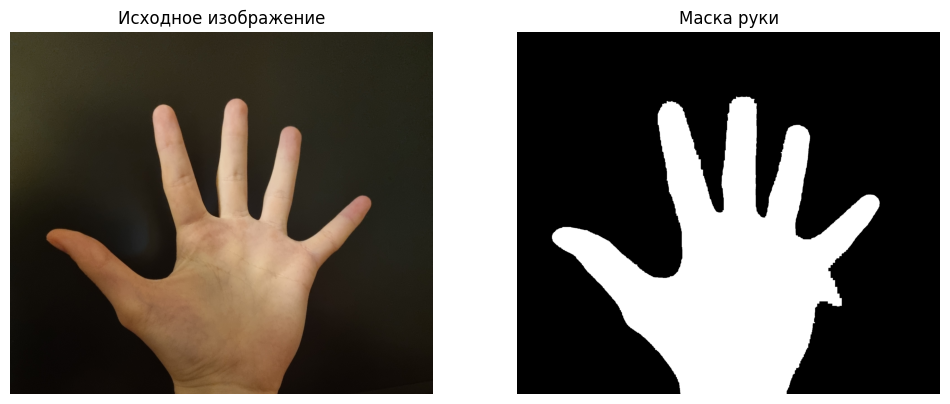

In [85]:
img_bgr = cv2.imread("data/cool_hand.jpg")
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
skin_mask = cv2.inRange(
    ycrcb,
    np.array([0, 133, 77], dtype=np.uint8),
    np.array([255, 173, 127], dtype=np.uint8),
)

skin_mask = cv2.GaussianBlur(skin_mask, (5, 5), 0)
_, skin_mask = cv2.threshold(skin_mask, 0, 255, cv2.THRESH_BINARY)
skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8), iterations=1)
skin_mask = cv2.morphologyEx(skin_mask, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8), iterations=2)

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(skin_mask)
largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
hand_mask = np.uint8(labels == largest_label) * 255

plt.figure(figsize=(12, 5))
plt.subplot(121)
plt.imshow(img_rgb)
plt.title("Исходное изображение")
plt.axis("off")
plt.subplot(122)
plt.imshow(hand_mask, cmap="gray")
plt.title("Маска руки")
plt.axis("off");


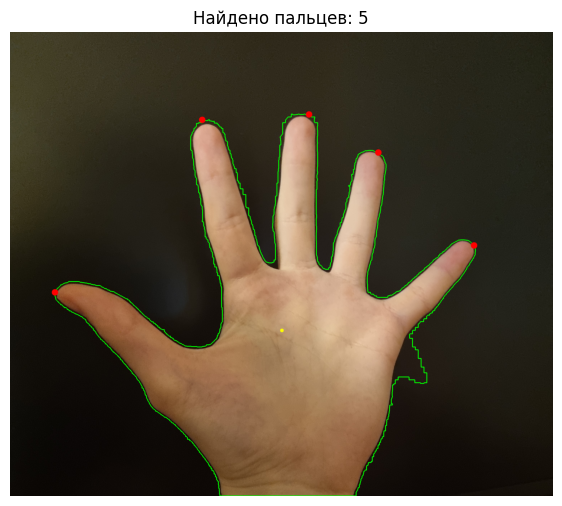

Количество пальцев на изображении: 5


In [86]:
contours, _ = cv2.findContours(hand_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
hand_contour = max(contours, key=cv2.contourArea)

moments = cv2.moments(hand_contour)
center = np.array([
    moments["m10"] / moments["m00"],
    moments["m01"] / moments["m00"],
])

_, _, _, h = cv2.boundingRect(hand_contour)
hull_points = cv2.convexHull(hand_contour)[:, 0, :]

candidates = []
for point in hull_points:
    if point[1] >= center[1] + 0.05 * h:
        continue

    distance = np.linalg.norm(point - center)
    angle = np.degrees(np.arctan2(-(point[1] - center[1]), point[0] - center[0]))
    candidates.append((angle, distance, point))

candidates.sort(key=lambda item: item[0])

clusters = []
angle_threshold = 12
for item in candidates:
    if not clusters or item[0] - clusters[-1][-1][0] > angle_threshold:
        clusters.append([item])
    else:
        clusters[-1].append(item)

fingertips = [max(cluster, key=lambda item: item[1])[2] for cluster in clusters]
finger_count = len(fingertips)

result = img_rgb.copy()
cv2.drawContours(result, [hand_contour], -1, (0, 255, 0), 3)
cv2.circle(result, tuple(np.int32(center)), 10, (255, 255, 0), -1)
for point in fingertips:
    cv2.circle(result, tuple(point), 18, (255, 0, 0), -1)

plt.figure(figsize=(7, 7))
plt.imshow(result)
plt.title(f"Найдено пальцев: {finger_count}")
plt.axis("off")
plt.show()

print(f"Количество пальцев на изображении: {finger_count}")
